# 2.6 Решение алгебраических и трансцендентных уравнений с помощью инструментальных средств

### Задание 1. Найдите методом половинного деления корень транцендетного уравнения lgx-cosx=0 с четырьмя знаками после запятой. Корни отделите графически.

In [125]:
from numpy import linspace, log10, cos, log, nan
import matplotlib.pyplot as plt

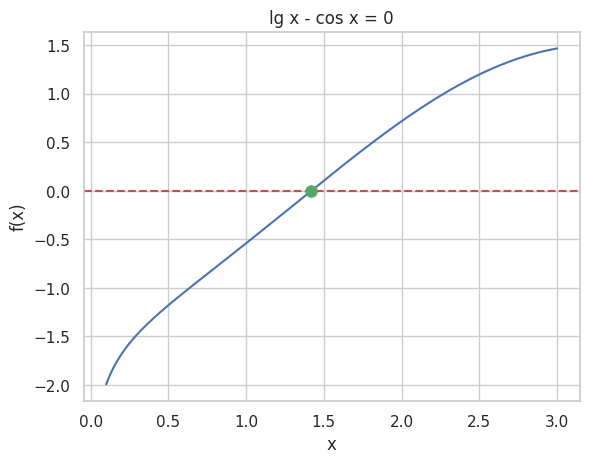

Корень: 1.4184


In [126]:
# Функция уравнения
def f(x):
    return log10(x) - cos(x)

# График
x = linspace(0.1, 3, 500)
plt.plot(x, f(x), 'b-')
plt.axhline(0, color='r', ls='--')
plt.grid(True)
plt.title('lg x - cos x = 0')
plt.xlabel('x')
plt.ylabel('f(x)')

# Метод половинного деления
a, b = 1.3, 1.5  
for _ in range(30):
    c = (a + b) / 2
    if f(a) * f(c) < 0:
        b = c
    else:
        a = c
    if (b - a) < 1e-5:
        break

# Точка на графике
plt.plot(c, 0, 'go', markersize=8)

plt.show()
print(f"Корень: {c:.4f}")

### Задание 2. Отделите графически корни уравнения х^2-3,2х=1. Найдите одним из итерационных методов действительный корень данного уравнения с точностью 10^-4

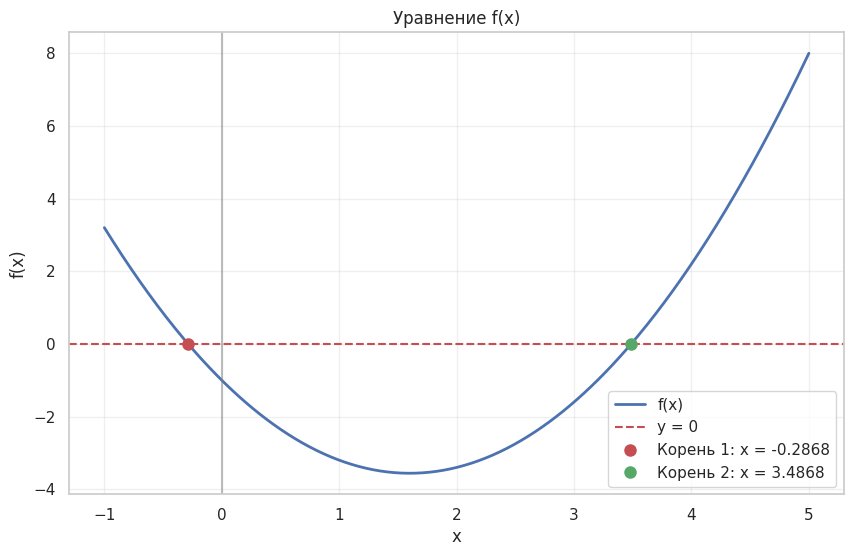

Корень 1: -0.2868
Корень 2: 3.4868


In [127]:
# Функция уравнения
def f(x):
    return x**2 - 3.2*x - 1

# Функция метода половинного деления
def half_division(a, b):
    for _ in range(30):
        c = (a + b) / 2
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
        if (b - a) < 1e-5:
            return c
    return c

# Находим корни
c1 = half_division(-1, 0)
c2 = half_division(3, 3.5)

# График
x = linspace(-1, 5, 400)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='f(x)')
plt.axhline(0, color='r', linestyle='--', label='y = 0')
plt.axvline(0, color='gray', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.plot(c1, 0, 'ro', markersize=8, label=f'Корень 1: x = {c1:.4f}')
plt.plot(c2, 0, 'go', markersize=8, label=f'Корень 2: x = {c2:.4f}')
plt.title('Уравнение f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

print(f"Корень 1: {c1:.4f}")
print(f"Корень 2: {c2:.4f}")

### Задание 3. Найдите наибольший положительный корень уравнения 4х-lnx=4 с точностью 10^-4,используя метод итераций. Корни отделите графически

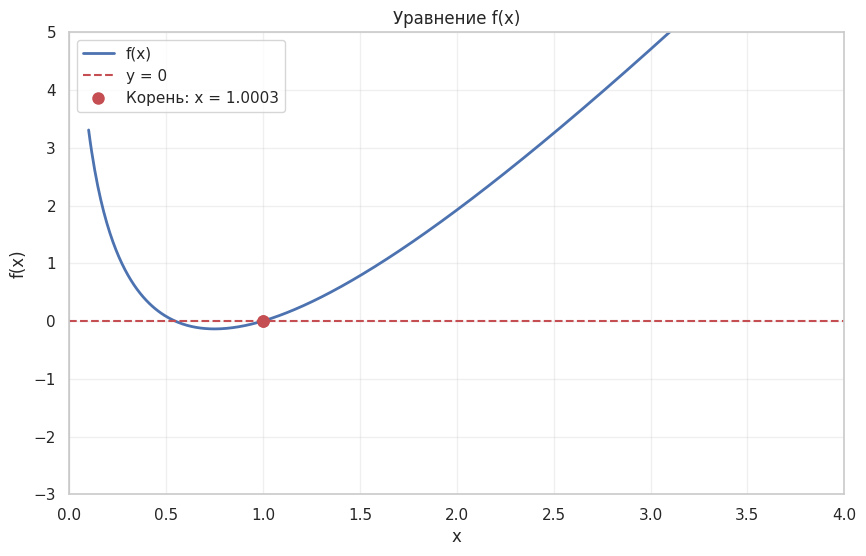

Наибольший положительный корень: 1.0003
Проверка: 4*1.0003 - 3ln(1.0003) = 4.000261 (должно быть 4)


In [128]:
def f(x):
    if x <= 0:
        return nan
    return 4*x - 3*log(x) - 4

#  метод итераций
x = 2.0
for i in range(30):
    x_new = (4 + 3*log(x)) / 4
    if abs(x_new - x) < 1e-4:
        break
    x = x_new

root = x_new

# график
x_vals = linspace(0.1, 4, 500)
y_vals = [f(val) for val in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x)')
plt.axhline(0, color='r', linestyle='--', label='y = 0')
plt.axvline(0, color='gray', alpha=0.5)
plt.grid(True, alpha=0.3)

# корень
plt.plot(root, 0, 'ro', markersize=8, label=f'Корень: x = {root:.4f}')
plt.plot(root, f(root), 'ro', markersize=8)

plt.title('Уравнение f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.xlim(0, 4)
plt.ylim(-3, 5)
plt.show()

print(f"Наибольший положительный корень: {root:.4f}")
print(f"Проверка: 4*{root:.4f} - 3ln({root:.4f}) = {4*root - 3*log(root):.6f} (должно быть 4)")